In [1]:
DATA_PATH = "/drive/MyDrive/llantas/encuesta2.xlsx" # Excel original
BASE_DIR = "/drive/MyDrive/llantas" # Nueva direccion
ENCUESTA_LIMPIA = "encuesta_limpia.xlsx"

In [2]:
# @title
mapas = {
        "auto_propio": {
            "sí": 1, "si": 1, "no": 0
        },

        "frec_cambio_llantas": {
            "menos de 1 año": 1,
            "1–2 años": 2, "1-2 años": 2,
            "2–3 años": 3, "2-3 años": 3,
            "más de 3 años": 4, "mas de 3 años": 4,
            "no sé": 0, "no se": 0
        },

        "tipo_de_residuo_perc": {
            "residuo peligroso": 1,
            "residuo especial (manejo especial)": 2,
            "residuo reciclable": 3,
            "no sé": 0, "no se": 0
        },

        "manejo_de_llantas_usadas": {
            "las tiro a la basura": 1,
            "las dejo en el taller donde las cambio": 2,
            "las vendo o reutilizo": 3,
            "las llevo a un centro de reciclaje": 4,
            "no sé / nunca lo he pensado": 0,
            "no se / nunca lo he pensado": 0
        },

        "impacto_ambiental_informed_lvl": {
            "Muy informado": 4,
            "Algo informado": 3,
            "Poco informado": 2,
            "Nada informado": 1
        },

        "tamano_del_problema_perc": {
            "Sí, es un problema muy grave": 4,
            "Sí, es un problema moderado": 3,
            "No, no es un problema grave": 2,
            "No lo había considerado":0
        },

        "destino_final_perc": {
            "sí, en talleres o vulcanizadoras": 1,
            "si, en talleres o vulcanizadoras": 1,
            "sí, en terrenos baldíos/ en la calle": 2,
            "si, en terrenos baldíos/ en la calle": 2,
            "sí, en rellenos sanitarios": 3,
            "si, en rellenos sanitarios": 3,
            "sí, en centros de reciclaje especializados": 4,
            "si, en centros de reciclaje especializados": 4,
            "no, no lo sé": 0,
            "no, no lo se": 0,
            "nunca lo he pensado": 0
        },

        "responsable_llantas_perc": {
            "el gobierno": 1,
            "las empresas fabricantes": 2,
            "los talleres/servicios automotrices": 3,
            "el consumidor": 4,
            "todos los anteriores": 5
        },

        "dispuesto_pagar": {
            "no": 1,
            "no estoy seguro": 2,
            "sí, si es un costo bajo": 3,
            "si, si es un costo bajo": 3,
            "sí, sin problema": 4,
            "si, sin problema": 4
        },

        "posibles_motivaciones": {
            "incentivos económicos (descuentos, dinero)": 1,
            "incentivos economicos (descuentos, dinero)": 1,
            "mayor información/conciencia ambiental": 2,
            "mayor informacion/conciencia ambiental": 2,
            "facilidad de acceso a centros de acopio": 3,
            "regulaciones/multas": 4
        },

        "econom_circular_perc": {
            "no, no sé qué es": 1,
            "no, no se que es": 1,
            "he escuchado el término pero no lo entiendo completamente": 2,
            "he escuchado el termino pero no lo entiendo completamente": 2,
            "sí, sé bien qué es y cómo funciona": 3,
            "si, se bien que es y como funciona": 3,
            "no estoy seguro/a": 0
        }
    }

In [3]:
# @title
newcolumns={'con_qué_género_te_identificas' : 'genero',
                        'de_qué_estado_eres_originario' : 'estado_originario',
                        'en_qué_estado_vives_actualmente' : 'estado_actual',
                        'tienes_automóvil_propio' : 'auto_propio',
                        'cada_cuánto_cambias_las_llantas_de_tu_automóvil_o_el_automóvil_de_tu_familia': 'frec_cambio_llantas',
                        'sabes_qué_tipo_de_residuo_son_las_llantas' : 'tipo_de_residuo_perc',
                        'qué_haces_con_tus_llantas_usadas' : 'manejo_de_llantas_usadas',
                        'qué_tan_informado_estás_sobre_el_impacto_ambiental_de_las_llantas' : 'impacto_ambiental_informed_lvl',
                        'sabes_dónde_se_desechan_las_llantas_o_cuál_es_su_destino_final_en_méxico': 'destino_final_perc',
                        'quién_consideras_responsable_del_manejo_adecuado_de_las_llantas_usadas' : 'responsable_llantas_perc',
                        'consideras_grave_el_desperdicio_y_la_forma_en_que_se_disponen_las_llantas_después_de_su_uso_en_méxico' : 'tamano_del_problema_perc',
                        'estarías_dispuesto_a_pagar_un_costo_adicional_para_que_tus_llantas_sean_recicladas_correctamente' : 'dispuesto_pagar',
                        'qué_te_motivaría_más_a_disponer_correctamente_tus_llantas' : 'posibles_motivaciones',
                        'conoces_qué_es_la_economía_circular' : 'econom_circular_perc'}

Aun se requiere limpiar manualmente: estado de origen y estado actual

# 1-5) Editado del df

---
## 1) Setup

In [4]:
# Bibliotecas

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import plotly.express as px
import plotly.io as pio

import os, sys, math, gc, warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import drive
drive.mount("/drive")

Mounted at /drive


In [6]:
# Opciones de pandas para inspección
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 140)

In [7]:
# Path de datos y de resultados

# Ruta del archivo


sys.path.insert(0, BASE_DIR) #para acceder a archivos utilitarios desde Colab-Drive
os.makedirs(BASE_DIR, exist_ok=True)




print(f"BASE_DIR: {BASE_DIR}")
print(f"Archivo de datos: {DATA_PATH}")

BASE_DIR: /drive/MyDrive/llantas
Archivo de datos: /drive/MyDrive/llantas/encuesta2.xlsx


In [8]:
def snake_case(col: str) -> str:
    """Convierte nombres de columnas a snake_case conservando significado."""
    col = col.strip()
    # Reemplaza paréntesis y guiones por espacios
    col = re.sub(r"[()\-]", " ", col)
    # Quita caracteres raros salvo letras/números/espacios/guion bajo
    col = re.sub(r"[^\w\s]", "", col, flags=re.UNICODE)
    col = col.lower()
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def normalize_str(x):
    """Normaliza strings: strip + espacios consistentes. Mantiene NaN."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def split_multiselect(x, sep=";"):
    """Convierte campos multi-selección (separados por ;) a lista limpia."""
    if pd.isna(x):
        return []
    parts = [p.strip() for p in str(x).split(sep)]
    parts = [p for p in parts if p]  # elimina vacíos
    return parts

print("Librerías y configuración cargadas.")


def nps_category(x):
  if pd.isna(x):
    return np.nan
  if x <= 6:
    return "Detractor (0-6)"
  if x <= 8:
    return "Pasivo (7-8)"
  return "Promotor (9-10)"



Librerías y configuración cargadas.


---
## 2) Carga de datos
**Técnica utilizada:** *inspección inicial* para detectar desde temprano problemas típicos (tipos mal leídos, columnas vacías, etc.).


In [9]:
df_raw = pd.read_excel(DATA_PATH)

# Drop unwanted columns (now that they are in snake_case)
columns_to_drop = ['ID','Start time', 'Completion time', 'Email', 'Name', 'Last modified time']
df = df_raw.drop(columns=columns_to_drop, errors='ignore')

In [10]:
print("Shape:", df.shape)

Shape: (139, 15)


In [11]:
print("\nTipos de datos:")
display(df.dtypes)


Tipos de datos:


,0
¿Con qué género te identificas?\n,object
Edad\n,object
¿De qué estado eres originario?\n,object
¿En qué estado vives actualmente?\n,object
¿Tienes automóvil propio?\n,object
¿Cada cuánto cambias las llantas de tu automóvil o el automóvil de tu familia?\n,object
¿Sabes qué tipo de residuo son las llantas?\n,object
¿Qué haces con tus llantas usadas?,object
¿Qué tan informado estás sobre el impacto ambiental de las llantas?\n,object
¿Sabes dónde se desechan las llantas o cuál es su destino final en México?\n,object


---
## 3) Perfilado rápido del dataset
Antes de limpiar, conviene responder:
- ¿Qué columnas hay y qué significan (por nombre)?
- ¿Cuántos faltantes hay por columna?
- ¿Hay duplicados exactos?
- ¿Qué tan “ruidoso” es el texto (espacios, valores inconsistentes, etc.)?

**Técnicas utilizadas:** *missingness audit*, *detección de duplicados*, *resumen estadístico*.


In [12]:
# Faltantes por columna
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts[na_counts > 0].to_frame("n_faltantes"))

,n_faltantes


In [13]:
# Duplicados exactos (todas las columnas)
n_dups = df.duplicated().sum()
print("Duplicados exactos (todas las columnas):", n_dups)


Duplicados exactos (todas las columnas): 0


In [14]:
df.describe()

,¿Con qué género te identificas?\n,Edad\n,¿De qué estado eres originario?\n,¿En qué estado vives actualmente?\n,¿Tienes automóvil propio?\n,¿Cada cuánto cambias las llantas de tu automóvil o el automóvil de tu familia?\n,¿Sabes qué tipo de residuo son las llantas?\n,¿Qué haces con tus llantas usadas?,¿Qué tan informado estás sobre el impacto ambiental de las llantas?\n,¿Sabes dónde se desechan las llantas o cuál es su destino final en México?\n,¿Quién consideras responsable del manejo adecuado de las llantas usadas?\n,¿Consideras grave el desperdicio y la forma en que se disponen las llantas después de su uso en México?\n,¿Estarías dispuesto a pagar un costo adicional para que tus llantas sean recicladas correctamente?\n,¿Qué te motivaría más a disponer correctamente tus llantas?\n,¿Conoces qué es la economía circular?\n
count,139,139,139,139,139,139,139,139,139,139,139,139,139,139,139
unique,2,47,55,47,2,5,4,5,4,6,5,4,4,4,4
top,Femenino,18,Jalisco,Baja California,Sí,Más de 3 años,Residuo especial (manejo especial),Las dejo en el taller donde las cambio,Poco informado,"No, no lo sé",Todos los anteriores,"Sí, es un problema muy grave","Sí, si es un costo bajo",Mayor información/conciencia ambiental,He escuchado el término pero no lo entiendo co...
freq,72,22,16,20,105,49,58,101,62,63,76,66,71,48,47


In [15]:
# Resumen numérico (si aplica)
num_cols_raw = df.select_dtypes(include="number").columns
if len(num_cols_raw) > 0:
    display(df[num_cols_raw].describe().T)
else:
    print("No se detectaron columnas numéricas en la lectura inicial.")


No se detectaron columnas numéricas en la lectura inicial.


---
## 4) Limpieza y estandarización



### 4.1 Estandarizar nombres de columnas y normalizar strings

In [16]:
# 1) renombrar columnas
old_cols = list(df.columns)
df.columns = [snake_case(c) for c in df.columns]

# 2) normalizar strings
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].apply(normalize_str)

### 4.2 Renombraminetos especiales

In [17]:
#Renombramientos especiales
df = df.rename(columns={'con_qué_género_te_identificas' : 'genero',
                        'de_qué_estado_eres_originario' : 'estado_originario',
                        'en_qué_estado_vives_actualmente' : 'estado_actual',
                        'tienes_automóvil_propio' : 'auto_propio',
                        'cada_cuánto_cambias_las_llantas_de_tu_automóvil_o_el_automóvil_de_tu_familia': 'frec_cambio_llantas',
                        'sabes_qué_tipo_de_residuo_son_las_llantas' : 'tipo_de_residuo_perc',
                        'qué_haces_con_tus_llantas_usadas' : 'manejo_de_llantas_usadas',
                        'qué_tan_informado_estás_sobre_el_impacto_ambiental_de_las_llantas' : 'impacto_ambiental_informed_lvl',
                        'sabes_dónde_se_desechan_las_llantas_o_cuál_es_su_destino_final_en_méxico': 'destino_final_perc',
                        'quién_consideras_responsable_del_manejo_adecuado_de_las_llantas_usadas' : 'responsable_llantas_perc',
                        'consideras_grave_el_desperdicio_y_la_forma_en_que_se_disponen_las_llantas_después_de_su_uso_en_méxico' : 'tamano_del_problema_perc',
                        'estarías_dispuesto_a_pagar_un_costo_adicional_para_que_tus_llantas_sean_recicladas_correctamente' : 'dispuesto_pagar',
                        'qué_te_motivaría_más_a_disponer_correctamente_tus_llantas' : 'posibles_motivaciones',
                        'conoces_qué_es_la_economía_circular' : 'econom_circular_perc'})

print("Columnas restantes y renombradas:")
for c in df.columns:
    print(f"- {c}")

Columnas restantes y renombradas:
- genero
- edad
- estado_originario
- estado_actual
- auto_propio
- frec_cambio_llantas
- tipo_de_residuo_perc
- manejo_de_llantas_usadas
- impacto_ambiental_informed_lvl
- destino_final_perc
- responsable_llantas_perc
- tamano_del_problema_perc
- dispuesto_pagar
- posibles_motivaciones
- econom_circular_perc


In [18]:
df

,genero,edad,estado_originario,estado_actual,auto_propio,frec_cambio_llantas,tipo_de_residuo_perc,manejo_de_llantas_usadas,impacto_ambiental_informed_lvl,destino_final_perc,responsable_llantas_perc,tamano_del_problema_perc,dispuesto_pagar,posibles_motivaciones,econom_circular_perc
0,Femenino,21,Jalisco,Jalisco,No,1–2 años,Residuo especial (manejo especial),Las dejo en el taller donde las cambio,Muy informado,"Sí, en rellenos sanitarios",Todos los anteriores,"Sí, es un problema muy grave","Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"Sí, sé bien qué es y cómo funciona"
1,Femenino,18,Ciudad de México,Ciudad de México,No,Más de 3 años,Residuo especial (manejo especial),Las vendo o reutilizo,Poco informado,"No, no lo sé",Todos los anteriores,No lo había considerado,No estoy seguro,Regulaciones/multas,He escuchado el término pero no lo entiendo co...
2,Femenino,21,Jalisco,Jalisco,No,No sé,No sé,No sé / nunca lo he pensado,Nada informado,Nunca lo he pensado,Todos los anteriores,No lo había considerado,"Sí, sin problema",Mayor información/conciencia ambiental,He escuchado el término pero no lo entiendo co...
3,Femenino,18,Estado de México,Guadalajara,No,2–3 años,No sé,No sé / nunca lo he pensado,Nada informado,Nunca lo he pensado,Todos los anteriores,"Sí, es un problema muy grave","Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,He escuchado el término pero no lo entiendo co...
4,Femenino,19,Guanajuato,Jalisco,Sí,2–3 años,Residuo especial (manejo especial),Las dejo en el taller donde las cambio,Poco informado,Nunca lo he pensado,Todos los anteriores,"Sí, es un problema moderado","Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"No, no sé qué es"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Masculino,19,Veracruz,Xalapa,Sí,1–2 años,No sé,No sé / nunca lo he pensado,Nada informado,Nunca lo he pensado,Todos los anteriores,No lo había considerado,No,Facilidad de acceso a centros de acopio,"No, no sé qué es"
135,Masculino,18,Veracruz,Veracruz,Sí,2–3 años,Residuo reciclable,Las llevo a un centro de reciclaje,Muy informado,"No, no lo sé",Las empresas fabricantes,"Sí, es un problema muy grave","Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"No, no sé qué es"
136,Masculino,17,Veracruz,Veracruz,No,Más de 3 años,Residuo reciclable,Las vendo o reutilizo,Muy informado,"Sí, en centros de reciclaje especializados",Las empresas fabricantes,"No, no es un problema grave","Sí, si es un costo bajo","Incentivos económicos (descuentos, dinero)",He escuchado el término pero no lo entiendo co...
137,Masculino,17,Veracruz,Veracruz,No,1–2 años,No sé,No sé / nunca lo he pensado,Poco informado,Nunca lo he pensado,Las empresas fabricantes,"Sí, es un problema muy grave","Sí, si es un costo bajo",Regulaciones/multas,No estoy seguro/a


---
## 5) Conversión de tipos y variables derivadas
**Técnicas utilizadas:** *casting seguro*, *feature engineering* con reglas de negocio.


### 5.1) Ajuste a variables numericas


#### 5.11) edad. num -> num + limpieza

In [19]:
def clean_edad(edad_val):
    if pd.isna(edad_val): # Handle NaN values
        return np.nan

    edad_str = str(edad_val).strip().lower()

    # Case 1: '43 años' -> 43
    match_anios = re.match(r'(\d+)\s*años', edad_str)
    if match_anios:
        return int(match_anios.group(1))

    # Case 2: '50-60' -> 55 (average)
    match_range = re.match(r'(\d+)\s*-\s*(\d+)', edad_str)
    if match_range:
        lower = int(match_range.group(1))
        upper = int(match_range.group(2))
        return (lower + upper) / 2

    # Case 3: Simple number (e.g., '21')
    if edad_str.isdigit():
        return int(edad_str)

    if edad_val.isnumeric():
        return int(edad_val)
    # Default: return NaN for unhandled formats
    return np.nan

df['edad'] = df['edad'].apply(clean_edad)
df['edad'] = pd.to_numeric(df['edad'], errors='coerce')

print("Verificando la columna 'edad' después de la limpieza:")
display(df[['edad']].head())
print("Tipo de dato de 'edad':", df['edad'].dtype)
df.describe()

Verificando la columna 'edad' después de la limpieza:


,edad
0,21.0
1,18.0
2,21.0
3,18.0
4,19.0


Tipo de dato de 'edad': float64


,edad
count,137.000000
mean,36.824818
std,17.342102
min,16.000000
25%,19.000000
50%,39.000000
75%,52.000000
max,75.000000


#### 5.12) impacto_ambiental_informed_lvl. string -> Discreto (1-4)

In [20]:
# 6.1 Convertir 'No aplica' a NaN y castear a numérico si corresponde

df.impacto_ambiental_informed_lvl = df.impacto_ambiental_informed_lvl.replace(
    {
     "Muy informado": 4,
     "Algo informado": 3,
     "Poco informado": 2,
     "Nada informado": 1
    })

df.impacto_ambiental_informed_lvl = pd.to_numeric(df.impacto_ambiental_informed_lvl, errors="coerce")

#### 5.13) tamano_del_problema_perc. string -> Discreto  (1-4)

In [21]:

df.tamano_del_problema_perc = df.tamano_del_problema_perc.replace(
    {
     "Sí, es un problema muy grave": 4,
     "Sí, es un problema moderado": 3,
     "No, no es un problema grave": 2,
     "No lo había considerado": 1
    })

df.tamano_del_problema_perc = pd.to_numeric(df.tamano_del_problema_perc, errors="coerce")

---
# 6) df final

In [22]:
df

,genero,edad,estado_originario,estado_actual,auto_propio,frec_cambio_llantas,tipo_de_residuo_perc,manejo_de_llantas_usadas,impacto_ambiental_informed_lvl,destino_final_perc,responsable_llantas_perc,tamano_del_problema_perc,dispuesto_pagar,posibles_motivaciones,econom_circular_perc
0,Femenino,21.0,Jalisco,Jalisco,No,1–2 años,Residuo especial (manejo especial),Las dejo en el taller donde las cambio,4,"Sí, en rellenos sanitarios",Todos los anteriores,4,"Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"Sí, sé bien qué es y cómo funciona"
1,Femenino,18.0,Ciudad de México,Ciudad de México,No,Más de 3 años,Residuo especial (manejo especial),Las vendo o reutilizo,2,"No, no lo sé",Todos los anteriores,1,No estoy seguro,Regulaciones/multas,He escuchado el término pero no lo entiendo co...
2,Femenino,21.0,Jalisco,Jalisco,No,No sé,No sé,No sé / nunca lo he pensado,1,Nunca lo he pensado,Todos los anteriores,1,"Sí, sin problema",Mayor información/conciencia ambiental,He escuchado el término pero no lo entiendo co...
3,Femenino,18.0,Estado de México,Guadalajara,No,2–3 años,No sé,No sé / nunca lo he pensado,1,Nunca lo he pensado,Todos los anteriores,4,"Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,He escuchado el término pero no lo entiendo co...
4,Femenino,19.0,Guanajuato,Jalisco,Sí,2–3 años,Residuo especial (manejo especial),Las dejo en el taller donde las cambio,2,Nunca lo he pensado,Todos los anteriores,3,"Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"No, no sé qué es"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Masculino,19.0,Veracruz,Xalapa,Sí,1–2 años,No sé,No sé / nunca lo he pensado,1,Nunca lo he pensado,Todos los anteriores,1,No,Facilidad de acceso a centros de acopio,"No, no sé qué es"
135,Masculino,18.0,Veracruz,Veracruz,Sí,2–3 años,Residuo reciclable,Las llevo a un centro de reciclaje,4,"No, no lo sé",Las empresas fabricantes,4,"Sí, si es un costo bajo",Facilidad de acceso a centros de acopio,"No, no sé qué es"
136,Masculino,17.0,Veracruz,Veracruz,No,Más de 3 años,Residuo reciclable,Las vendo o reutilizo,4,"Sí, en centros de reciclaje especializados",Las empresas fabricantes,2,"Sí, si es un costo bajo","Incentivos económicos (descuentos, dinero)",He escuchado el término pero no lo entiendo co...
137,Masculino,17.0,Veracruz,Veracruz,No,1–2 años,No sé,No sé / nunca lo he pensado,2,Nunca lo he pensado,Las empresas fabricantes,4,"Sí, si es un costo bajo",Regulaciones/multas,No estoy seguro/a


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

Funcion cuando estados estan normalizados

In [24]:
# @title
def convertir_categoricas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte columnas categóricas a valores numéricos
    usando los nombres de columnas normalizados del dataframe.

    No modifica columnas sin regla definida, como:
    - genero
    - edad
    """

    df_num = df.copy()

    # =========================
    # Mapeo de estados
    # =========================
    estados_map = {
        "aguascalientes": 1,
        "baja california": 2,
        "baja california sur": 3,
        "campeche": 4,
        "chiapas": 5,
        "chihuahua": 6,
        "coahuila": 7,
        "colima": 8,
        "durango": 9,
        "guanajuato": 10,
        "guerrero": 11,
        "hidalgo": 12,
        "jalisco": 13,
        "mexico": 14,
        "michoacan": 15,
        "morelos": 16,
        "nayarit": 17,
        "nuevo leon": 18,
        "oaxaca": 19,
        "puebla": 20,
        "queretaro": 21,
        "quintana roo": 22,
        "san luis potosi": 23,
        "sinaloa": 24,
        "sonora": 25,
        "tabasco": 26,
        "tamaulipas": 27,
        "tlaxcala": 28,
        "veracruz": 29,
        "yucatan": 30,
        "zacatecas": 31
    }

    # =========================
    # Diccionarios de mapeo
    # =========================
    mapas = {
        "estado_originario": estados_map,
        "estado_actual": estados_map,

        "auto_propio": {
            "sí": 1,
            "si": 1,
            "no": 0
        },

        "frec_cambio_llantas": {
            "menos de 1 año": 1,
            "1–2 años": 2,
            "1-2 años": 2,
            "2–3 años": 3,
            "2-3 años": 3,
            "más de 3 años": 4,
            "mas de 3 años": 4,
            "no sé": 0,
            "no se": 0
        },

        "tipo_de_residuo_perc": {
            "residuo peligroso": 1,
            "residuo especial (manejo especial)": 2,
            "residuo reciclable": 3,
            "no sé": 0,
            "no se": 0
        },

        "manejo_de_llantas_usadas": {
            "las tiro a la basura": 1,
            "las dejo en el taller donde las cambio": 2,
            "las vendo o reutilizo": 3,
            "las llevo a un centro de reciclaje": 4,
            "no sé / nunca lo he pensado": 0,
            "no se / nunca lo he pensado": 0
        },

        "impacto_ambiental_informed_lvl": {
            "nada informado": 1,
            "poco informado": 2,
            "algo informado": 3,
            "muy informado": 4
        },

        "destino_final_perc": {
            "sí, en talleres o vulcanizadoras": 1,
            "si, en talleres o vulcanizadoras": 1,
            "sí, en terrenos baldíos/ en la calle": 2,
            "si, en terrenos baldíos/ en la calle": 2,
            "sí, en rellenos sanitarios": 3,
            "si, en rellenos sanitarios": 3,
            "sí, en centros de reciclaje especializados": 4,
            "si, en centros de reciclaje especializados": 4,
            "no, no lo sé": 0,
            "no, no lo se": 0,
            "nunca lo he pensado": 0
        },

        "responsable_llantas_perc": {
            "el gobierno": 1,
            "las empresas fabricantes": 2,
            "los talleres/servicios automotrices": 3,
            "el consumidor": 4,
            "todos los anteriores": 5
        },

        "tamano_del_problema_perc": {
            "no, no es un problema grave": 1,
            "sí, es un problema moderado": 2,
            "si, es un problema moderado": 2,
            "sí, es un problema muy grave": 3,
            "si, es un problema muy grave": 3,
            "no lo había considerado": 0,
            "no lo habia considerado": 0
        },

        "dispuesto_pagar": {
            "no": 1,
            "no estoy seguro": 2,
            "sí, si es un costo bajo": 3,
            "si, si es un costo bajo": 3,
            "sí, sin problema": 4,
            "si, sin problema": 4
        },

        "posibles_motivaciones": {
            "incentivos económicos (descuentos, dinero)": 1,
            "incentivos economicos (descuentos, dinero)": 1,
            "mayor información/conciencia ambiental": 2,
            "mayor informacion/conciencia ambiental": 2,
            "facilidad de acceso a centros de acopio": 3,
            "regulaciones/multas": 4
        },

        "econom_circular_perc": {
            "no, no sé qué es": 1,
            "no, no se que es": 1,
            "he escuchado el término pero no lo entiendo completamente": 2,
            "he escuchado el termino pero no lo entiendo completamente": 2,
            "sí, sé bien qué es y cómo funciona": 3,
            "si, se bien que es y como funciona": 3,
            "no estoy seguro/a": 0
        }
    }

    # =========================
    # Aplicar mapeos
    # =========================
    for columna, mapa in mapas.items():
        if columna in df_num.columns:
            df_num[columna] = (
                df_num[columna]
                .astype(str)
                .str.strip()
                .str.lower()
                .map(mapa)
            )

    return df_num

Funcion cuando no estan normalizados

In [25]:
def convertir_categoricas(df: pd.DataFrame,mapas=mapas) -> pd.DataFrame:
    df_num = df.copy()

    columnas_ya_numericas = [
        "impacto_ambiental_informed_lvl",
        "tamano_del_problema_perc"
    ]

    for columna, mapa in mapas.items():
        if columna in df_num.columns:

            # CLAVE: saltar si ya es numérica
            if columna in columnas_ya_numericas:
                if pd.api.types.is_numeric_dtype(df_num[columna]):
                    continue

            original = df_num[columna].copy()

            normalizada = (
                df_num[columna]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            df_num[columna] = normalizada.map(mapa)

            no_reconocidos = original[df_num[columna].isna() & original.notna()].unique()

            if len(no_reconocidos) > 0:
                print(f"\n⚠ Valores no reconocidos en '{columna}':")
                for v in no_reconocidos:
                    print(f"   - {v}")

    return df_num

In [26]:
df_encoded = convertir_categoricas(df)
print("DataFrame 'df_encoded' creado con columnas categóricas convertidas.")
df_encoded


DataFrame 'df_encoded' creado con columnas categóricas convertidas.


,genero,edad,estado_originario,estado_actual,auto_propio,frec_cambio_llantas,tipo_de_residuo_perc,manejo_de_llantas_usadas,impacto_ambiental_informed_lvl,destino_final_perc,responsable_llantas_perc,tamano_del_problema_perc,dispuesto_pagar,posibles_motivaciones,econom_circular_perc
0,Femenino,21.0,Jalisco,Jalisco,0,2,2,2,4,3,5,4,3,3,3
1,Femenino,18.0,Ciudad de México,Ciudad de México,0,4,2,3,2,0,5,1,2,4,2
2,Femenino,21.0,Jalisco,Jalisco,0,0,0,0,1,0,5,1,4,2,2
3,Femenino,18.0,Estado de México,Guadalajara,0,3,0,0,1,0,5,4,3,3,2
4,Femenino,19.0,Guanajuato,Jalisco,1,3,2,2,2,0,5,3,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Masculino,19.0,Veracruz,Xalapa,1,2,0,0,1,0,5,1,1,3,1
135,Masculino,18.0,Veracruz,Veracruz,1,3,3,4,4,0,2,4,3,3,1
136,Masculino,17.0,Veracruz,Veracruz,0,4,3,3,4,4,2,2,3,1,2
137,Masculino,17.0,Veracruz,Veracruz,0,2,0,0,2,0,2,4,3,4,0


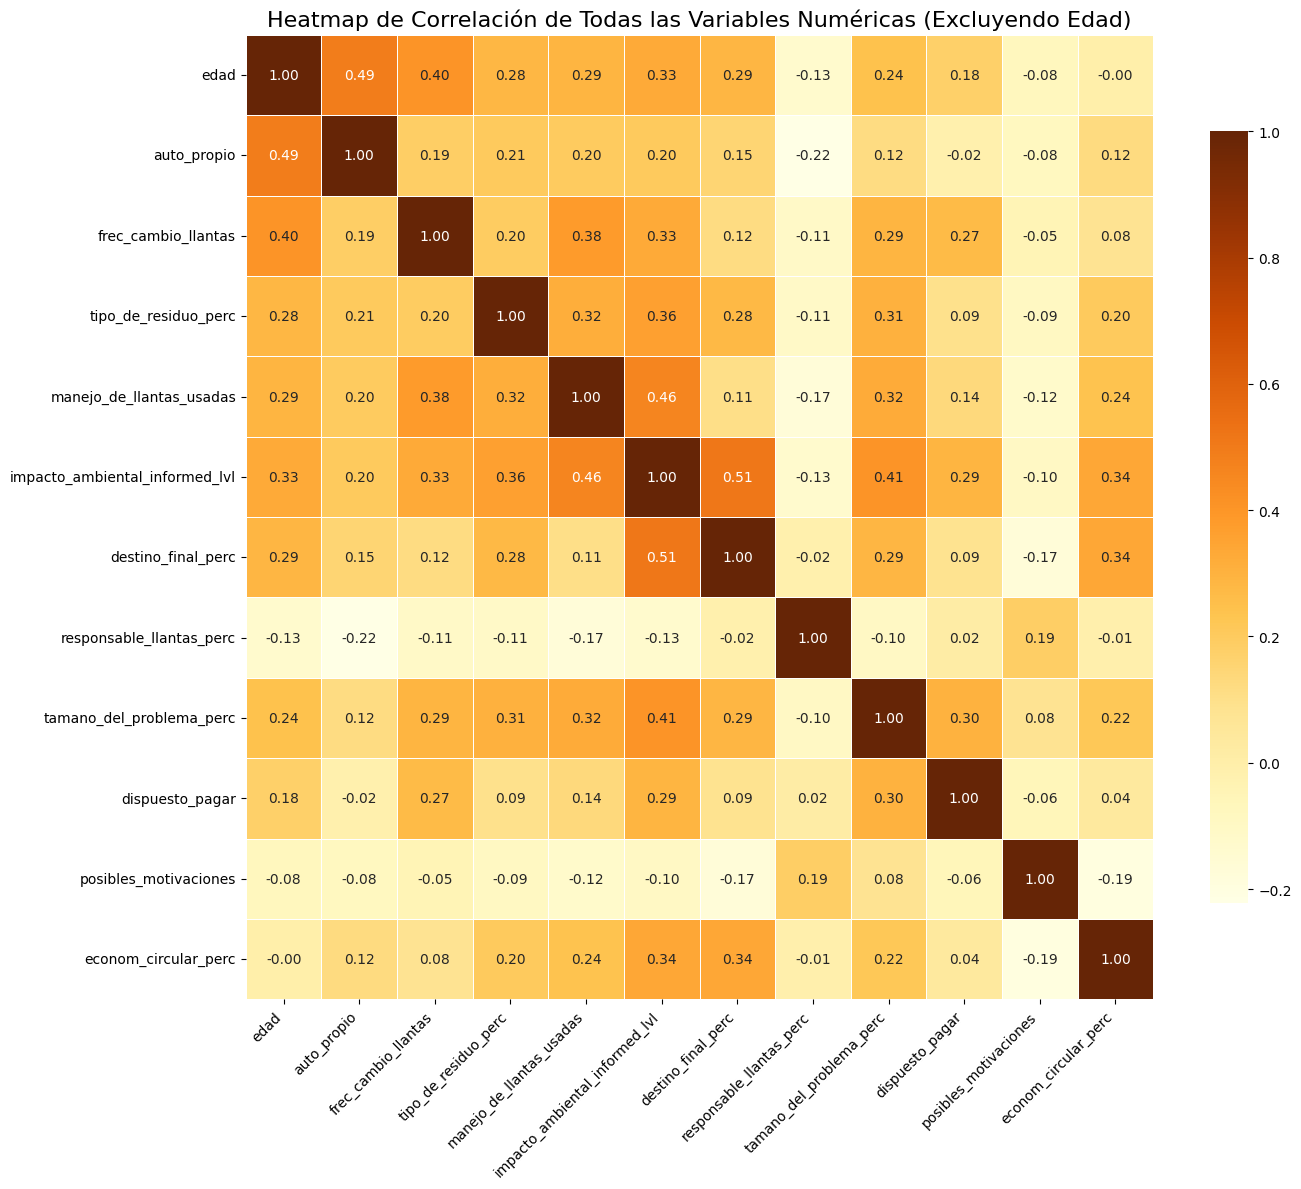

In [27]:
# Eliminar la columna 'edad' de df_encoded para este heatmap
df_encoded_without_edad = df_encoded.drop('rango_edad', axis=1, errors='ignore')

# Seleccionar todas las columnas numéricas para el heatmap
numeric_cols_for_heatmap = df_encoded_without_edad.select_dtypes(include=['number']).columns

# Calcular la matriz de correlación
correlation_matrix_encoded = df_encoded_without_edad[numeric_cols_for_heatmap].corr()

# Crear el heatmap
plt.figure(figsize=(14, 12)) # Ajustar tamaño para mejor visualización
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='YlOrBr', fmt=".2f", linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Heatmap de Correlación de Todas las Variables Numéricas (Excluyendo Edad)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# @title
print("Las 7 correlaciones más fuertes (ignorando auto-correlaciones y duplicados):")

# Convertir la matriz de correlación en una serie para facilitar el filtrado y ordenamiento
corr_series = correlation_matrix_encoded.unstack()

# Eliminar auto-correlaciones (donde el nombre de la columna es igual al índice)
# y eliminar pares duplicados (ej: A-B y B-A)
strong_correlations = corr_series[corr_series.index.get_level_values(0) != corr_series.index.get_level_values(1)]
strong_correlations = strong_correlations.abs().sort_values(ascending=False)

# Para evitar duplicados como (A,B) y (B,A), podemos iterar y mantener solo una de cada par.
# Una forma más sencilla es filtrar el triangulo superior o inferior de la matriz original
# y luego unstack (o simplemente filtrar la serie unstacked).
# Pero como ya tenemos el abs y ordenado, solo necesitamos seleccionar los únicos.

# Crear un set para almacenar los pares ya procesados (para evitar duplicados)
processed_pairs = set()
final_strong_correlations = []

for (col1, col2), value in strong_correlations.items():
    # Asegurarse de que el par sea siempre en el mismo orden (ej: (A,B) en lugar de (B,A))
    sorted_pair = tuple(sorted((col1, col2)))

    if sorted_pair not in processed_pairs:
        final_strong_correlations.append(((col1, col2), value))
        processed_pairs.add(sorted_pair)

    if len(final_strong_correlations) >= 7:
        break

# Imprimir las 7 correlaciones más fuertes
for (col1, col2), value in final_strong_correlations:
    original_value = correlation_matrix_encoded.loc[col1, col2]
    print(f"  - {col1} y {col2}: {original_value:.2f} (Valor absoluto: {value:.2f})")

Las 7 correlaciones más fuertes (ignorando auto-correlaciones y duplicados):
  - destino_final_perc y impacto_ambiental_informed_lvl: 0.51 (Valor absoluto: 0.51)
  - edad y auto_propio: 0.49 (Valor absoluto: 0.49)
  - impacto_ambiental_informed_lvl y manejo_de_llantas_usadas: 0.46 (Valor absoluto: 0.46)
  - tamano_del_problema_perc y impacto_ambiental_informed_lvl: 0.41 (Valor absoluto: 0.41)
  - edad y frec_cambio_llantas: 0.40 (Valor absoluto: 0.40)
  - frec_cambio_llantas y manejo_de_llantas_usadas: 0.38 (Valor absoluto: 0.38)
  - impacto_ambiental_informed_lvl y tipo_de_residuo_perc: 0.36 (Valor absoluto: 0.36)


####plot_frequency_scatter_with_regression(df, var1, var2)


---
# 7) Plots exploratorios (EDA)
El objetivo es **ver el comportamiento global** del dataset y detectar señales:
- sesgos fuertes,
- distribuciones,
- asociación entre variables (correlación),
- “top items” en multi-selección.

> En encuestas, un EDA útil no es “hacer muchas gráficas”, sino graficar lo que **responde preguntas**.


#### -> Helpers

In [29]:
def invertir_mapas(mapas=mapas):
    mapas_invertidos = {}
    for col, mapping in mapas.items():
        mapas_invertidos[col] = {v: k for k, v in mapping.items()}
    return mapas_invertidos

def get_original_labels_for_column(series, inverted_map):
    """
    Convierte una serie de valores numéricos categóricos a sus etiquetas de texto originales.

    Args:
        series (pd.Series): Serie numérica con categorías.
        inverted_map (dict): Diccionario invertido de mapeo (número -> texto).

    Returns:
        list: Lista de etiquetas de texto originales.
    """
    # Obtener los ticks únicos y ordenarlos
    ticks = sorted(series.dropna().unique())
    # Mapear los ticks a sus etiquetas originales
    labels = [inverted_map.get(t, str(t)) for t in ticks]
    return labels


def original_col(df, var, newcolumns=newcolumns):
    # Invertir nombres de columnas: normalizado -> original
    original_columns = {v: k for k, v in newcolumns.items()}

    # Obtener nombres originales para mostrar en gráfica
    display_var = original_columns.get(var, var)

    display_var = display_var.replace("_", " ").strip().capitalize()

    # Agregar signos de interrogación
    display_var = f"¿{display_var}?"
    return display_var

In [30]:
def plot_frequency_scatter_with_regression(df, var1, var2, mapas_dict=None, newcolumns_dict=None, line=True):
    """
    Genera un scatter plot con frecuencia por tamaño de punto,
    línea de regresión, labels categóricos en ejes y nombres
    originales de columnas en título y ejes.

    Args:
        df (pd.DataFrame): DataFrame de entrada.
        var1 (str): Nombre de la columna normalizada para eje x.
        var2 (str): Nombre de la columna normalizada para eje y.
        mapas_dict (dict): Diccionario global de mappings texto -> número. If None, tries to use global 'mapas'.
        newcolumns_dict (dict): Diccionario original -> normalizado. If None, tries to use global 'newcolumns'.
    """
    if mapas_dict is None:
        mapas_dict = globals().get('mapas')
        if mapas_dict is None:
            raise NameError("The 'mapas' dictionary must be defined globally or passed as an argument to 'plot_frequency_scatter_with_regression'.")

    if newcolumns_dict is None:
        newcolumns_dict = globals().get('newcolumns')
        if newcolumns_dict is None:
            raise NameError("The 'newcolumns' dictionary must be defined globally or passed as an argument to 'plot_frequency_scatter_with_regression'.")

    # Invertir mapas de categorías: número -> texto
    mapas_inv = invertir_mapas(mapas_dict)

    display_var1 = original_col(df, var1, newcolumns_dict)
    display_var2 = original_col(df, var2, newcolumns_dict)

    # Agrupar por frecuencia de pares
    grouped_data = df.groupby([var1, var2]).size().reset_index(name='point_count')

    # Calcular porcentaje para la leyenda
    total_df_responses = df.shape[0]
    grouped_data['percentage'] = (grouped_data['point_count'] / total_df_responses * 100).round(1)

    plt.figure(figsize=(12, 8)) # Increased figure size

    # Scatter con tamaño por frecuencia
    sns.scatterplot(
        data=grouped_data,
        x=var1,
        y=var2,
        size='point_count',
        sizes=(50, 1000),
        hue='point_count', # Keep hue as point_count for numerical color mapping
        legend='full'
    )

    # Línea de regresión
    if line:
      sns.regplot(
          data=df,
          x=var1,
          y=var2,
          scatter=False,
          color='red',
          line_kws={'linestyle': '--', 'alpha': 0.7},
          ax=plt.gca()
      )

    ax = plt.gca()

    # Labels del eje X usando categorías originales con conteo y porcentaje
    if var1 in mapas_inv:
        # Get unique numeric values for the axis
        unique_x_numeric_values = sorted(df[var1].dropna().unique())

        # Calculate counts and percentages for var1
        var1_value_counts = df[var1].value_counts()
        var1_value_percentages = (df[var1].value_counts(normalize=True) * 100).round(1)

        formatted_x_labels = []
        for val in unique_x_numeric_values:
            original_label = mapas_inv[var1].get(val, str(val))
            count = var1_value_counts.get(val, 0)
            percentage = var1_value_percentages.get(val, 0.0)
            formatted_x_labels.append(f"{original_label}\n({count} - {percentage:.1f}%)")

        ax.set_xticks(unique_x_numeric_values)
        ax.set_xticklabels(formatted_x_labels, rotation=30, ha='right')

    # Labels del eje Y usando categorías originales con conteo y porcentaje
    if var2 in mapas_inv:
        # Get unique numeric values for the axis
        unique_y_numeric_values = sorted(df[var2].dropna().unique())

        # Calculate counts and percentages for var2
        var2_value_counts = df[var2].value_counts()
        var2_value_percentages = (df[var2].value_counts(normalize=True) * 100).round(1)

        formatted_y_labels = []
        for val in unique_y_numeric_values:
            original_label = mapas_inv[var2].get(val, str(val))
            count = var2_value_counts.get(val, 0)
            percentage = var2_value_percentages.get(val, 0.0)
            formatted_y_labels.append(f"{original_label}\n({count} - {percentage:.1f}%)")

        ax.set_yticks(unique_y_numeric_values)
        ax.set_yticklabels(formatted_y_labels)

    # Customizar la leyenda para añadir el porcentaje
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []

    # Create a mapping from point_count value to its percentage
    # Use .first() to handle cases where multiple (var1, var2) pairs have the same point_count
    percentage_map = grouped_data.groupby('point_count')['percentage'].first().to_dict()

    # Determine if the first label is a title or a data point.
    # If the first label is non-numeric, it's probably the title.
    is_first_label_title = False
    if labels: # Ensure labels list is not empty
        try:
            # Try converting the first label to a number. If it fails, it's probably a title.
            float(labels[0])
        except ValueError:
            is_first_label_title = True

    for i, label_str in enumerate(labels):
        if is_first_label_title and i == 0:
            new_labels.append(f"{label_str} \n") # Keep the title as is
        else:
            try:
                # Convert label to float first to handle potential "X.0" strings, then to int.
                pc_val_float = float(label_str)
                pc_val = int(pc_val_float) # Convert to int for dictionary lookup
                percent = percentage_map.get(pc_val, 0.0)
                new_labels.append(f"\n{pc_val} ({percent:.1f}%)")
            except ValueError:
                # Fallback if conversion fails for any other reason (e.g., unexpected format)
                new_labels.append(f"{label_str} \n")

    ax.legend(handles, new_labels, title='Conteo (Porcentaje)', bbox_to_anchor=(1, 1)) # Moved legend inside the plot

    plt.title(f'{display_var1} vs {display_var2}')
    plt.xlabel(display_var1)
    plt.ylabel(display_var2)

    # Reduce font size of tick labels to prevent wrapping
    plt.tick_params(axis='x', labelsize=8)
    plt.tick_params(axis='y', labelsize=8)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
# Helpers de plotting
def bar_top(series, top=15, title=None, xlabel=None, ylabel="Frecuencia"):
    vc = series.value_counts().head(top)
    ax = vc.plot(kind="bar")
    ax.set_title(title or "")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def hist(series, bins=11, title=None, xlabel=None):
    ax = series.dropna().plot(kind="hist", bins=bins)
    ax.set_title(title or "")
    ax.set_xlabel(xlabel or "")
    plt.tight_layout()
    plt.show()




In [32]:
def plot_categorical_frequency(df, column_name, mapas=mapas):
    """
    Genera un gráfico de barras de frecuencia y porcentaje para una columna categórica.

    Args:
        df (pd.DataFrame): El DataFrame de entrada.
        column_name (str): El nombre de la columna categórica a analizar.
        mapas (dict): Diccionario global de mappings texto -> número, para obtener el orden.
    """
    counts = df[column_name].value_counts().reset_index()
    counts.columns = ['categoria', 'conteo']

    # Filter out categories with 0 count
    counts = counts[counts['conteo'] > 0]

    # Calculate percentage
    total_responses = counts['conteo'].sum()
    counts['porcentaje'] = (counts['conteo'] / total_responses * 100).round(1)

    # Create text labels for display
    counts['text'] = counts.apply(lambda row: f"{row['conteo']} ({row['porcentaje']:.1f}%)", axis=1)

    # Define the correct order for the categories based on the maps dictionary
    category_order = None
    if column_name in mapas and isinstance(mapas[column_name], dict):
        # Try to get the order from the original keys in mapas, preserving their order
        category_order = [cat for cat in list(mapas[column_name].keys()) if cat in counts['categoria'].values]
        # Clean up the order to match the normalized values in the df if necessary
        # This part might need adjustment depending on how 'df[column_name]' values are stored
        # For this example, assuming they are the original strings.

    fig = px.bar(
        counts,
        x='categoria',
        y='conteo',
        text='text',
        title=f'Frecuencia de {column_name.replace("_", " ").title()}',
        labels={'categoria': column_name.replace("_", " ").title(), 'conteo': 'Cantidad de Encuestados'},
        category_orders={'categoria': category_order} if category_order else None
    )

    fig.update_traces(textposition='outside')
    fig.show()


## Graficas (POR COMPLETAR)

### 7.1) Graficas generales

In [33]:
# @title
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# --- 1. Rango de Edades --- #
bins = [0, 18, 20, 30, 40, 50, 60, df['edad'].max() + 1]
labels = ['<18','18-20', '20-30', '30-40', '40-50', '50-60', '>60']
df['rango_edad'] = pd.cut(df['edad'], bins=bins, labels=labels, right=False, ordered=True)

rango_edad_counts = df['rango_edad'].value_counts().reset_index()
rango_edad_counts.columns = ['rango_edad', 'conteo']
rango_edad_counts['rango_edad'] = pd.Categorical(rango_edad_counts['rango_edad'], categories=labels, ordered=True)
rango_edad_counts = rango_edad_counts.sort_values('rango_edad')

total_rango_edad = rango_edad_counts['conteo'].sum()
rango_edad_counts['percentage'] = (rango_edad_counts['conteo'] / total_rango_edad * 100).round(1)
rango_edad_counts['text'] = rango_edad_counts.apply(lambda row: f"{row['conteo']}<br>({row['percentage']}%) ", axis=1)

# --- 2. Distribución por Género --- #
genero_counts = df['genero'].value_counts().reset_index()
genero_counts.columns = ['genero', 'conteo']
total_genero = genero_counts['conteo'].sum()
genero_counts['percentage'] = (genero_counts['conteo'] / total_genero * 100).round(1)
genero_counts['text'] = genero_counts.apply(lambda row: f"{row['conteo']}<br>({row['percentage']}%) ", axis=1)

# --- 3. Distribución de Propiedad de Automóvil por Rango de Edad --- #
# Group by both auto_propio and rango_edad
auto_propio_rango_edad_counts = df.groupby(['rango_edad', 'auto_propio']).size().reset_index(name='conteo')

# Ensure correct categorical order for rango_edad
auto_propio_rango_edad_counts['rango_edad'] = pd.Categorical(auto_propio_rango_edad_counts['rango_edad'], categories=labels, ordered=True)
auto_propio_rango_edad_counts = auto_propio_rango_edad_counts.sort_values(['rango_edad', 'auto_propio'])

# Calculate percentages relative to the total for each auto_propio category within each rango_edad
auto_propio_rango_edad_counts['total_por_rango_edad'] = auto_propio_rango_edad_counts.groupby('rango_edad')['conteo'].transform('sum')
auto_propio_rango_edad_counts['percentage'] = (auto_propio_rango_edad_counts['conteo'] / auto_propio_rango_edad_counts['total_por_rango_edad'] * 100).round(1)
auto_propio_rango_edad_counts['text'] = auto_propio_rango_edad_counts.apply(lambda row: f"{row['conteo']}<br>({row['percentage']}%) ", axis=1)

# Separate data for 'Sí' and 'No' to add as different traces
auto_propio_si = auto_propio_rango_edad_counts[auto_propio_rango_edad_counts['auto_propio'] == 'Sí'].copy()
auto_propio_no = auto_propio_rango_edad_counts[auto_propio_rango_edad_counts['auto_propio'] == 'No'].copy()

# Ensure all age ranges are present for both 'Sí' and 'No' categories, filling missing with zeros
all_rango_edad_df = pd.DataFrame({'rango_edad': labels})

auto_propio_si = pd.merge(all_rango_edad_df, auto_propio_si, on='rango_edad', how='left').fillna({'conteo': 0, 'percentage': 0, 'text': '0<br>(0.0%) ', 'auto_propio': 'Sí', 'total_por_rango_edad': 0})
auto_propio_no = pd.merge(all_rango_edad_df, auto_propio_no, on='rango_edad', how='left').fillna({'conteo': 0, 'percentage': 0, 'text': '0<br>(0.0%) ', 'auto_propio': 'No', 'total_por_rango_edad': 0})

auto_propio_si['rango_edad'] = pd.Categorical(auto_propio_si['rango_edad'], categories=labels, ordered=True)
auto_propio_no['rango_edad'] = pd.Categorical(auto_propio_no['rango_edad'], categories=labels, ordered=True)

auto_propio_si = auto_propio_si.sort_values('rango_edad')
auto_propio_no = auto_propio_no.sort_values('rango_edad')


# Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Distribución de Edades por Rango',
        'Distribución por Género',
        'Distribución de Propiedad de Automóvil por Rango de Edad' # Updated title
    )
)

# Add Rango de Edad bar chart
fig.add_trace(
    go.Bar(
        x=rango_edad_counts['rango_edad'],
        y=rango_edad_counts['conteo'],
        text=rango_edad_counts['text'],
        textposition='outside',
        name='Rango de Edad',
        marker_color='#1f77b4',
        showlegend=False # Hide legend for this trace as x-axis label is sufficient
    ),
    row=1, col=1
)

# Add Género bar chart
fig.add_trace(
    go.Bar(
        x=genero_counts['genero'],
        y=genero_counts['conteo'],
        text=genero_counts['text'],
        textposition='outside',
        name='Género',
        marker_color='#ff7f0e',
        showlegend=False # Hide legend for this trace as x-axis label is sufficient
    ),
    row=1, col=2
)

# Add Auto Propio by Rango de Edad bar charts
fig.add_trace(
    go.Bar(
        x=auto_propio_si['rango_edad'],
        y=auto_propio_si['conteo'],
        text=auto_propio_si['text'],
        textposition='outside',
        name='Tiene Automóvil: Sí', # Updated name
        marker_color='#2ca02c', # Green for 'Sí'
        showlegend=True # Show legend for this trace
    ),
    row=1, col=3
)

fig.add_trace(
    go.Bar(
        x=auto_propio_no['rango_edad'],
        y=auto_propio_no['conteo'],
        text=auto_propio_no['text'],
        textposition='outside',
        name='Tiene Automóvil: No', # Updated name
        marker_color='#d62728', # Red for 'No'
        showlegend=True # Show legend for this trace
    ),
    row=1, col=3
)


# Update layout for combined figure
fig.update_layout(
    title_text='Análisis de Perfil de Encuestados',
    height=500,
    showlegend=True, # Set to True to allow individual trace legends to show
    margin=dict(t=50, b=50, l=50, r=50), # Adjust margins for better fit
    legend_title_text="Propiedad de Automóvil", # Add a title for the legend
    barmode='group' # Enable grouped bars for comparison
)

# Update x-axis categories for 'Rango de Edad' to ensure correct order
fig.update_xaxes(
    categoryorder='array',
    categoryarray=labels,
    title_text='Rango de Edad',
    row=1, col=1
)
fig.update_yaxes(
    title_text='Cantidad de Encuestados',
    row=1, col=1
)
fig.update_xaxes(
    title_text='Género',
    row=1, col=2
)
fig.update_yaxes(
    title_text='Cantidad de Encuestados',
    row=1, col=2
)
fig.update_xaxes( # Updated x-axis for the third subplot
    categoryorder='array',
    categoryarray=labels,
    title_text='Rango de Edad',
    row=1, col=3
)
fig.update_yaxes( # Updated y-axis for the third subplot
    title_text='Cantidad de Encuestados',
    row=1, col=3
)

fig.show()


### 7.4) Frecuencia de cambio de llantas

In [45]:
plot_categorical_frequency(df, 'posibles_motivaciones', mapas)

In [34]:
plot_categorical_frequency(df, 'frec_cambio_llantas', mapas)

In [35]:
plot_categorical_frequency(df, 'tipo_de_residuo_perc', mapas)

In [36]:
plot_categorical_frequency(df, 'manejo_de_llantas_usadas', mapas)

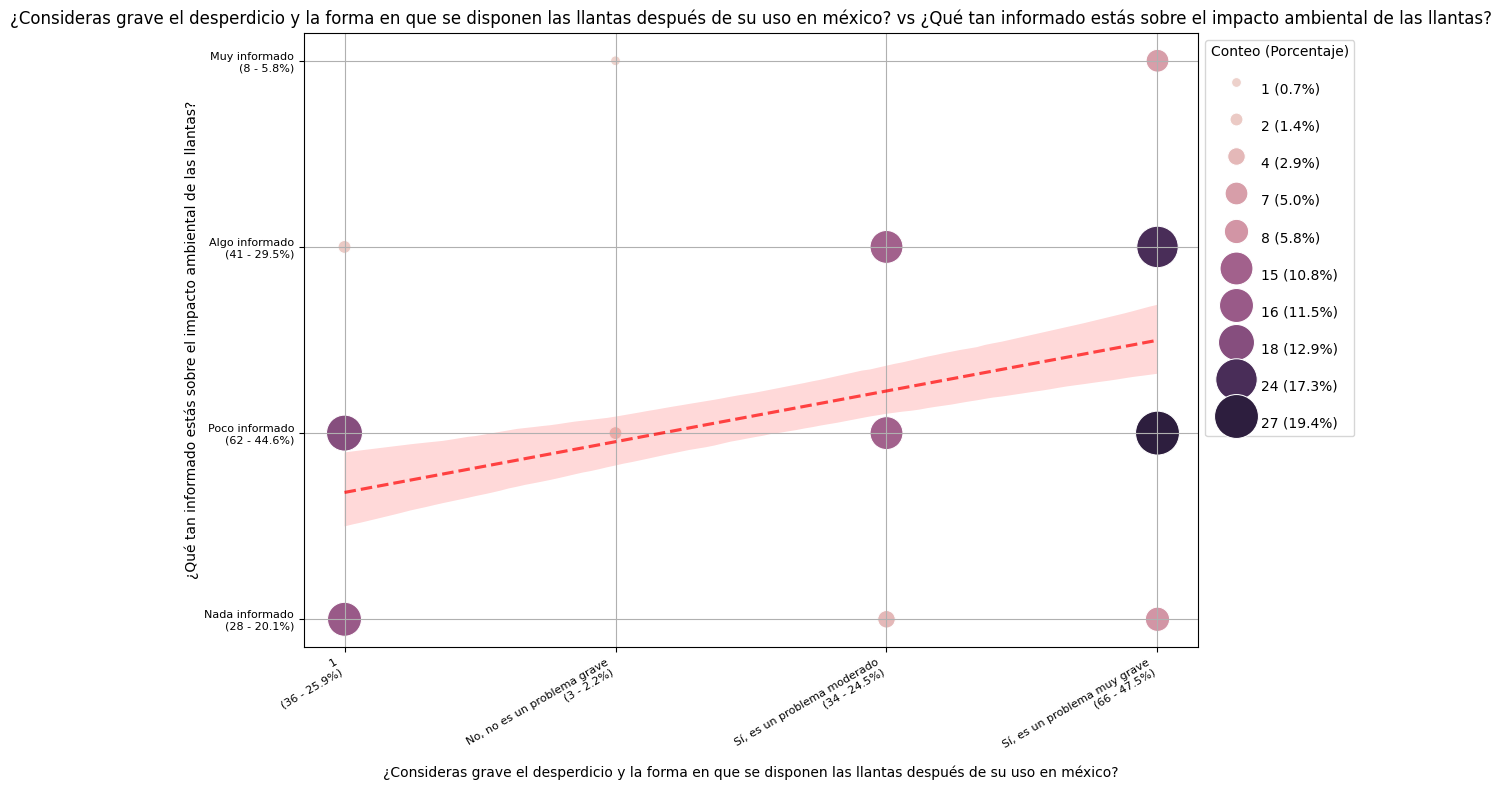

In [37]:
plot_frequency_scatter_with_regression(df_encoded_without_edad, 'tamano_del_problema_perc', 'impacto_ambiental_informed_lvl')

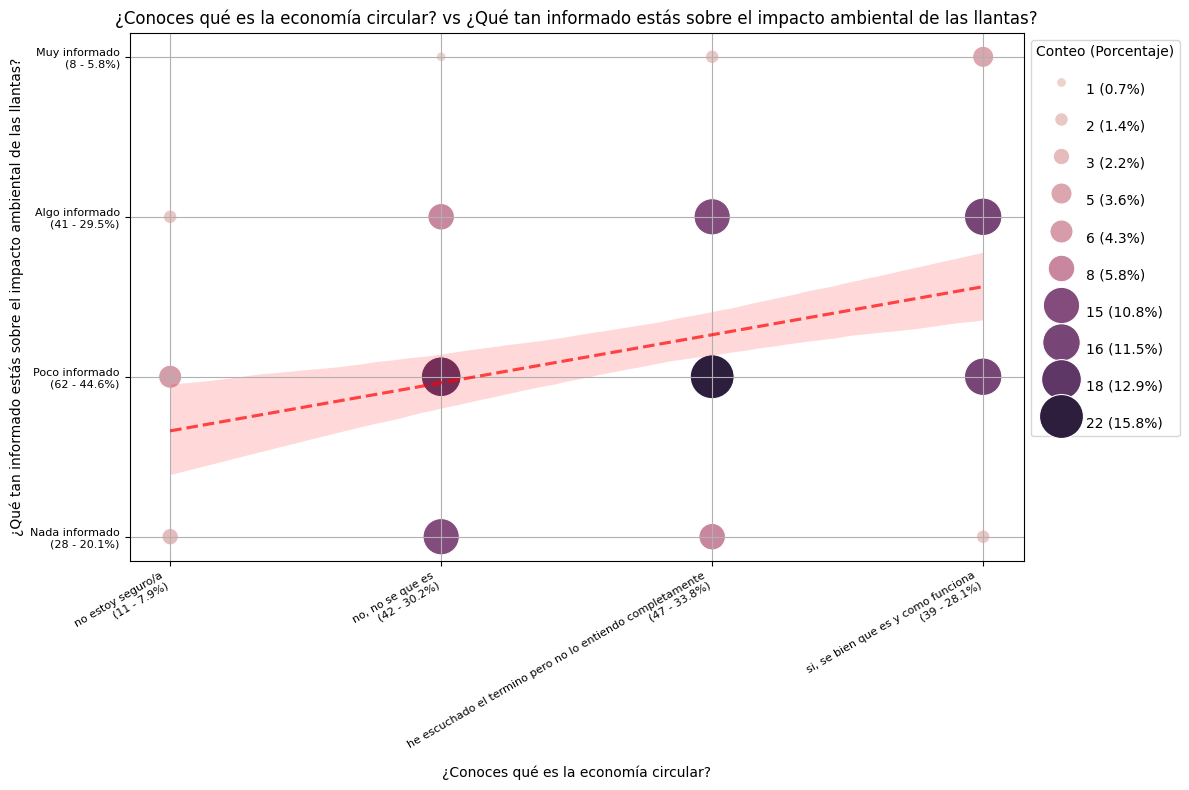

In [38]:
#   - impacto_ambiental_informed_lvl y econom_circular_perc: -0.34 (Valor absoluto: 0.34)
plot_frequency_scatter_with_regression(df_encoded_without_edad, 'econom_circular_perc', 'impacto_ambiental_informed_lvl')

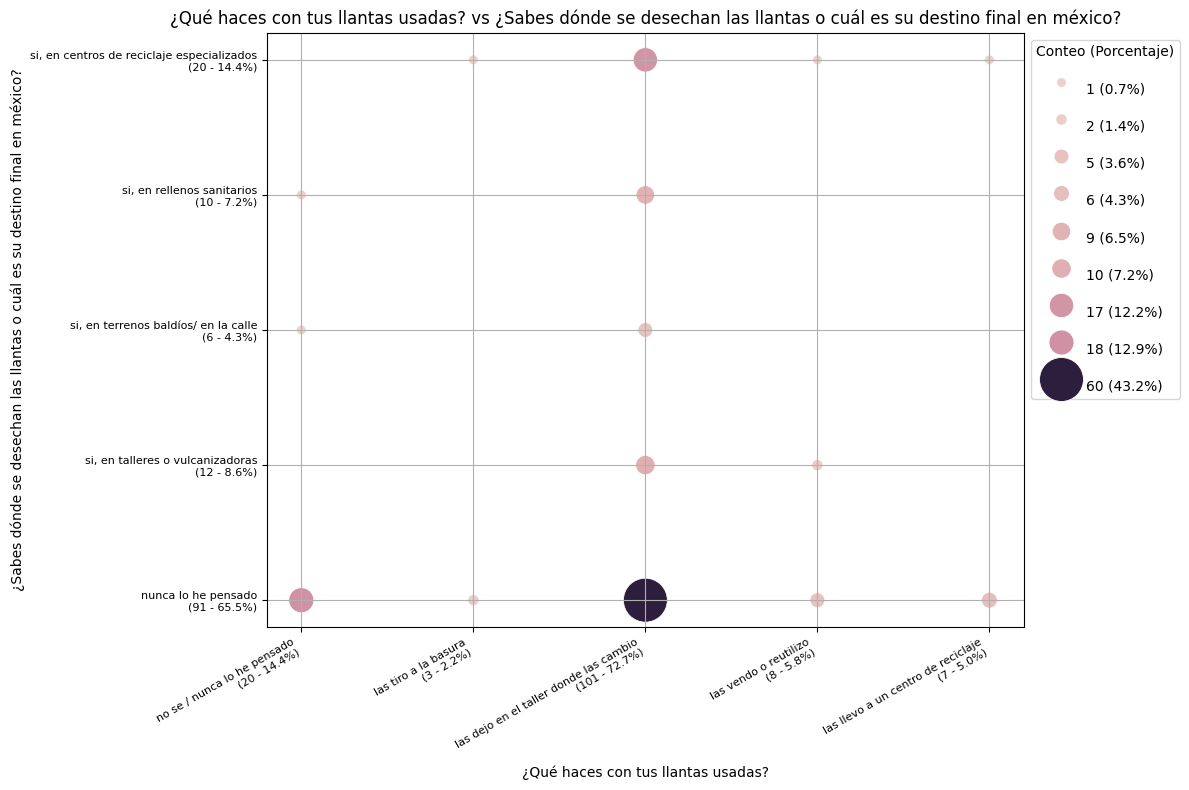

In [39]:
plot_frequency_scatter_with_regression(df_encoded_without_edad, 'manejo_de_llantas_usadas', 'destino_final_perc', line = False)

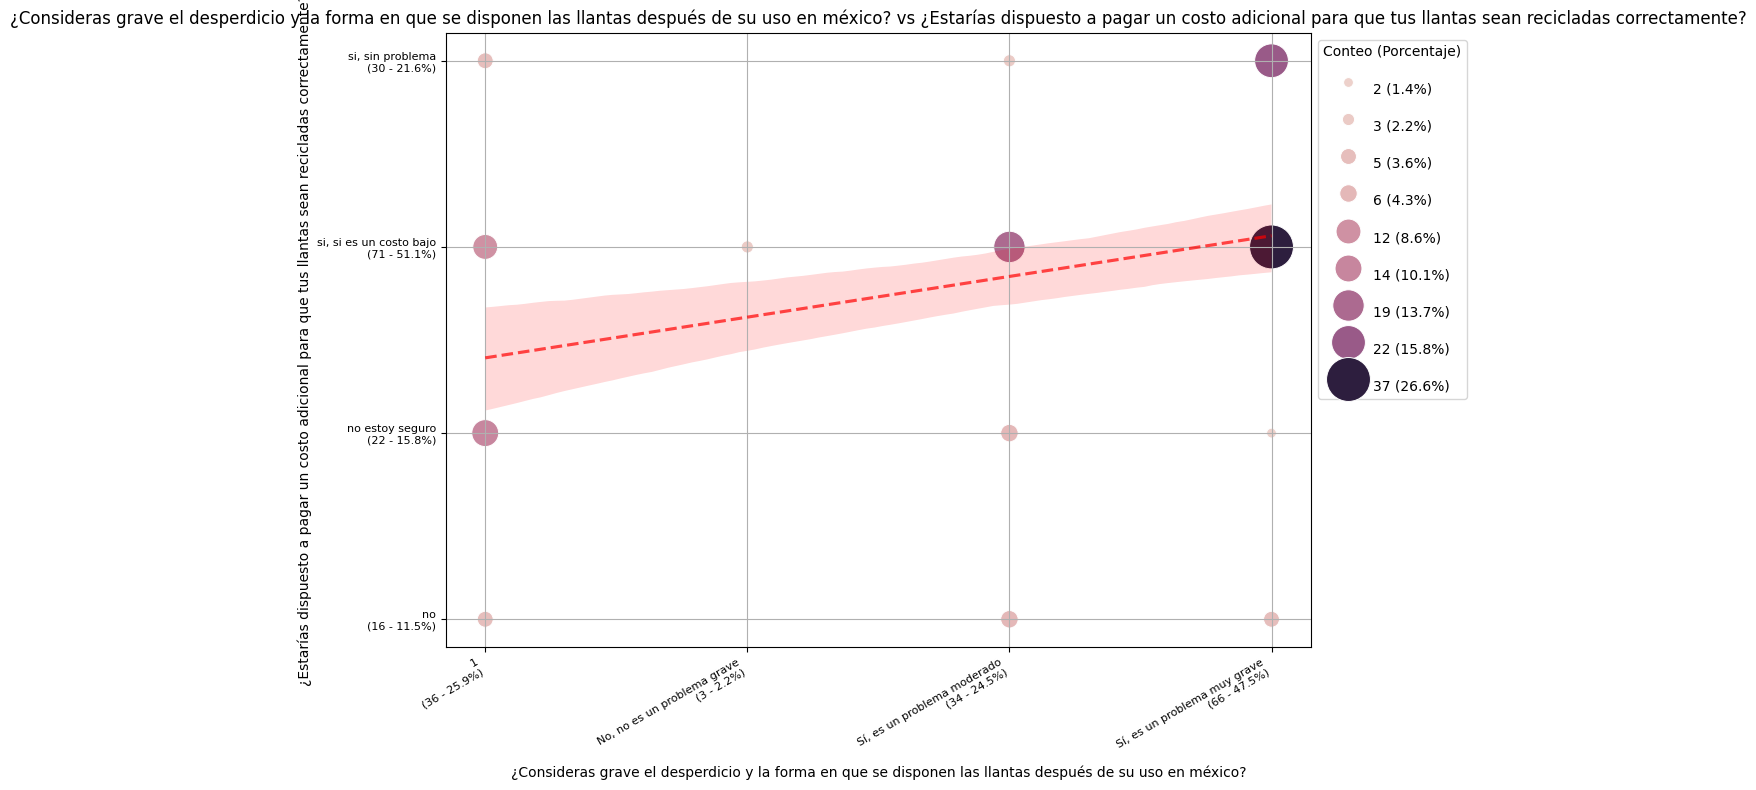

In [40]:
plot_frequency_scatter_with_regression(df_encoded_without_edad, 'tamano_del_problema_perc', 'dispuesto_pagar')

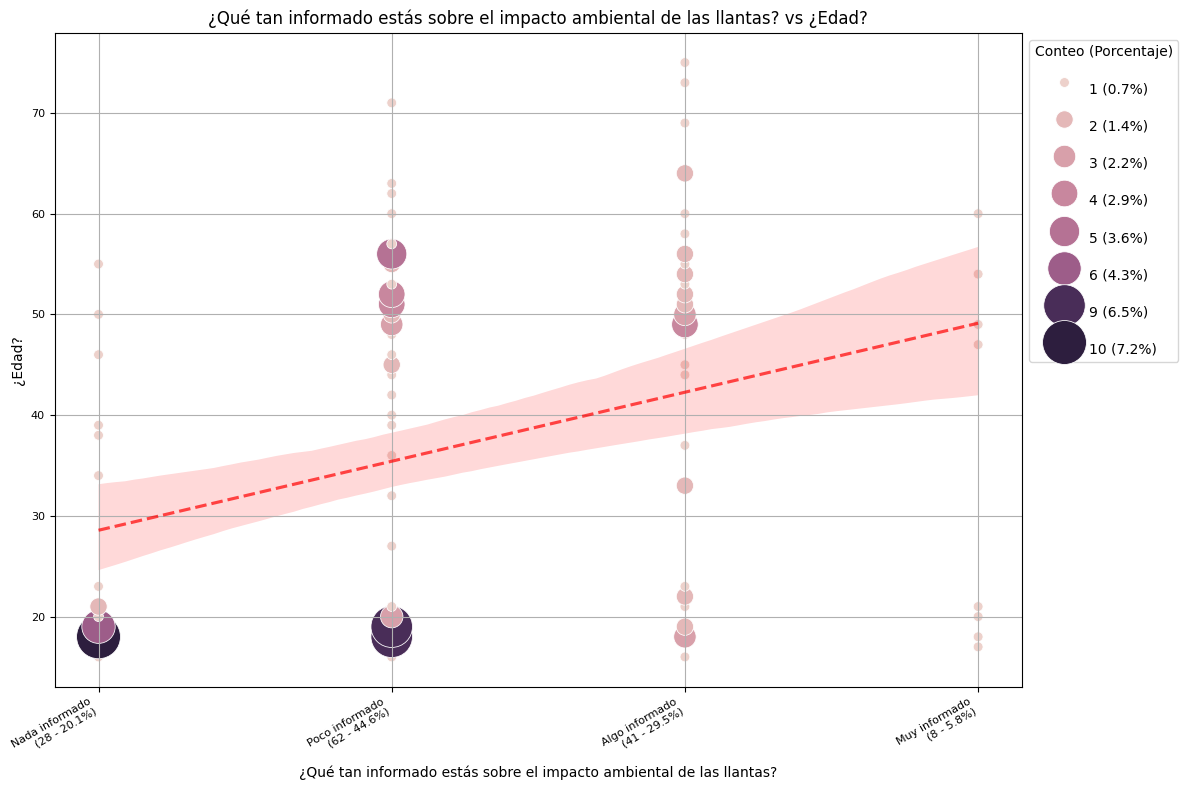

In [41]:
plot_frequency_scatter_with_regression(df_encoded_without_edad, 'impacto_ambiental_informed_lvl', 'edad')

In [42]:
# Invertir el mapeo para obtener las etiquetas originales de 'tamano_del_problema_perc'
mapas_invertidos = {v: k for k, v in mapas['tamano_del_problema_perc'].items()}

# Crear una columna temporal con las etiquetas originales para el eje x
df_temp = df.copy()
df_temp['tamano_del_problema_perc_labels'] = df_temp['tamano_del_problema_perc'].map(mapas_invertidos)

# Definir el orden de las categorías para el eje x
category_order = [
    'No lo había considerado',
    'No, no es un problema grave',
    'Sí, es un problema moderado',
    'Sí, es un problema muy grave'
]

# Crear el box plot usando Plotly Express
fig = px.box(
    df_temp,
    x='tamano_del_problema_perc_labels',
    y='edad',
    title='Distribución de Edad por Percepción del Tamaño del Problema',
    labels={
        'tamano_del_problema_perc_labels': 'Percepción del Tamaño del Problema',
        'edad': 'Edad'
    }
)

fig.update_xaxes(title_standoff=10)
fig.update_yaxes(title_standoff=10)

fig.show()

---
## 10) Guardar dataset limpio


In [43]:
OUT_CLEAN_PATH = os.path.join(BASE_DIR, ENCUESTA_LIMPIA)
df.to_excel(OUT_CLEAN_PATH)
print("Guardado:", OUT_CLEAN_PATH)

Guardado: /drive/MyDrive/llantas/encuesta_limpia.xlsx
